In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 5.5,
    'axes.titlesize': 5.5,
    'axes.labelsize': 5.5,
    'xtick.labelsize': 5.5,
    'ytick.labelsize': 5.5,
    'legend.fontsize': 5.5,
    'figure.titlesize': 5.5,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Read data
benchmark_df = pd.read_table('./data/Bagert_histone_mut.benchmark.tsv')
# Map phenotypes to binary values
benchmark_df['mutant phenotype'] = benchmark_df['mutant phenotype'].map({
    'No phenotype': 0,
    'No growth': 1,
    'Impaired growth': 1,
})
# Invert scores so that higher scores indicate higher pathogenicity
benchmark_df['HistMTR'] = -benchmark_df['HistMTR']
benchmark_df['RGC-MTR'] = -benchmark_df['RGC-MTR']

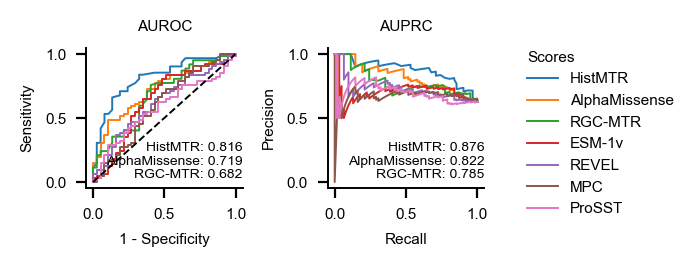

In [3]:
score_lst = benchmark_df.columns[3:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(2.5, 1.3))

# Calculate AUROC and AUPRC average scores and store them
roc_prc_aver_scores = []
for score in score_lst:
    fpr, tpr, _ = roc_curve(benchmark_df['mutant phenotype'], benchmark_df[score])
    auc_score = roc_auc_score(benchmark_df['mutant phenotype'], benchmark_df[score])
    precision, recall, _ = precision_recall_curve(benchmark_df['mutant phenotype'], benchmark_df[score])
    ap_score = average_precision_score(benchmark_df['mutant phenotype'], benchmark_df[score])
    roc_prc_aver_scores.append((score, auc_score, ap_score))

# Sort the scores in descending order
scores_sorted = sorted(roc_prc_aver_scores, key=lambda x: x[1], reverse=True)
sorted_score_lst_roc = [score for score, _, _ in scores_sorted]

# Plot curves in sorted order
handles = []
labels = []
score_descri_auroc = []
score_descri_auprc = []
for score, auc_score, ap_score in scores_sorted:
    fpr, tpr, _ = roc_curve(benchmark_df['mutant phenotype'], benchmark_df[score])
    precision, recall, _ = precision_recall_curve(benchmark_df['mutant phenotype'], benchmark_df[score])

    line, = ax1.plot(fpr, tpr, linewidth=0.7, label=f'{score}')
    handles.append(line)
    labels.append(line.get_label())
    ax2.plot(recall, precision, linewidth=0.7)

    score_descri_auroc.append(
        f'{score}: {auc_score:.3f}'
    )
    score_descri_auprc.append(
        f'{score}: {ap_score:.3f}'
    )

score_desci_text = '\n'.join(score_descri_auroc[0:3])
ax1.text(1, 0.05, score_desci_text, transform=ax1.transAxes,
        fontsize=5, horizontalalignment='right', verticalalignment='bottom',)
score_desci_text = '\n'.join(score_descri_auprc[0:3])
ax2.text(1, 0.05, score_desci_text, transform=ax2.transAxes,
        fontsize=5, horizontalalignment='right', verticalalignment='bottom',)

ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.7)
ax1.set_xlabel('1 - Specificity')
ax1.set_ylabel('Sensitivity')
ax1.set_title('AUROC')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('AUPRC')

fig.legend(handles, labels, loc='center left', title='Scores', alignment='left',
            bbox_to_anchor=(1.02, 0.5), frameon=False)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()